# Monte Carlo numerical diagnostics

Validate the numerical robustness of the projection-based state-evolution solver under particle-budget and rank-tolerance sweeps.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler


This is a solver-validation notebook, not a scientific performance experiment.  It varies $(K_w,K_g)$ and $\varepsilon_{\rm rank}$, then records macroscopic convergence, rank evolution, coordinate condition numbers, innovation scales, and empirical-basis orthogonality.

In [3]:
SEED = 10_100
T, DELTA = 70, 2.0
DATA_CFG = DataConfig(scale=1.0, label_prior=0.2, supervision_ratio=0.1, data_to_dimension_ratio=DELTA, signal_law=lambda: 0.0)
ALGO_CFG = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=logit(0.8))
LAW = FourCellSampleTypeLaw.product(label_prior=0.2, supervision_ratio=0.1)
BUDGETS = ((1_000, 1_300), (2_000, 2_600), (4_000, 5_200), (8_000, 10_400))
EPS_RANKS = (1e-12, 1e-10, 1e-8)

def run_solver(K_w, K_g, eps_rank, mc_seed=SEED):
    se = MacroscopicStateEvolution(
        data_cfg=DATA_CFG, algo_cfg=ALGO_CFG, mc_seed=mc_seed, K=None, K_w=K_w, K_g=K_g, eps_rank=eps_rank,
        parameter_base_sampler=make_parameter_base_sampler(1.0),
        sample_base_sampler=state_evolution_sample_base_sampler(LAW),
    )
    se.compute_trajectory()
    return se

solutions = {(K_w, K_g, eps): run_solver(K_w, K_g, eps) for K_w, K_g in BUDGETS for eps in EPS_RANKS}

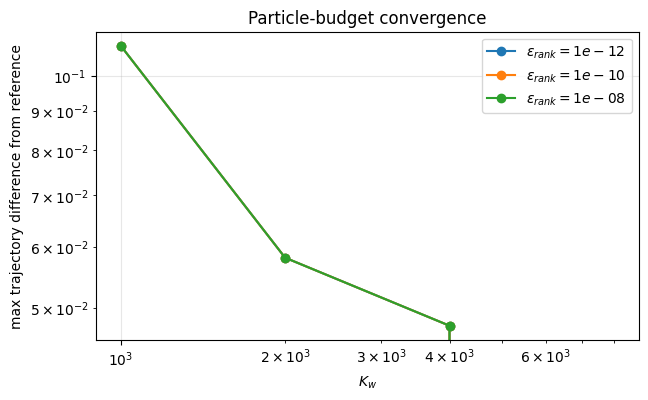

In [4]:
reference_key = (BUDGETS[-1][0], BUDGETS[-1][1], EPS_RANKS[0])
reference = solutions[reference_key]
reference_m = as_numpy(reference.weight_signal_alignments)
reference_chi = as_numpy(reference.label_residual_alignments)
reference_zeta = as_numpy(reference.mean_residual)
reference_omega = as_numpy(reference.selection_rate)

rows = []
for key, se in solutions.items():
    errors = [
        np.max(np.abs(as_numpy(se.weight_signal_alignments) - reference_m)),
        np.max(np.abs(as_numpy(se.label_residual_alignments) - reference_chi)),
        np.max(np.abs(as_numpy(se.mean_residual) - reference_zeta)),
        np.max(np.abs(as_numpy(se.selection_rate) - reference_omega)),
    ]
    rows.append((*key, *errors))
rows = np.asarray(rows)

fig, ax = plt.subplots(figsize=(7, 4))
for eps in EPS_RANKS:
    subset = rows[rows[:, 2] == eps]
    ax.loglog(subset[:, 0], np.max(subset[:, 3:], axis=1), marker="o", label=rf"$\varepsilon_{{rank}}={eps:.0e}$")
ax.set(xlabel=r"$K_w$", ylabel="max trajectory difference from reference", title="Particle-budget convergence")
ax.grid(alpha=0.3); ax.legend(); plt.show()

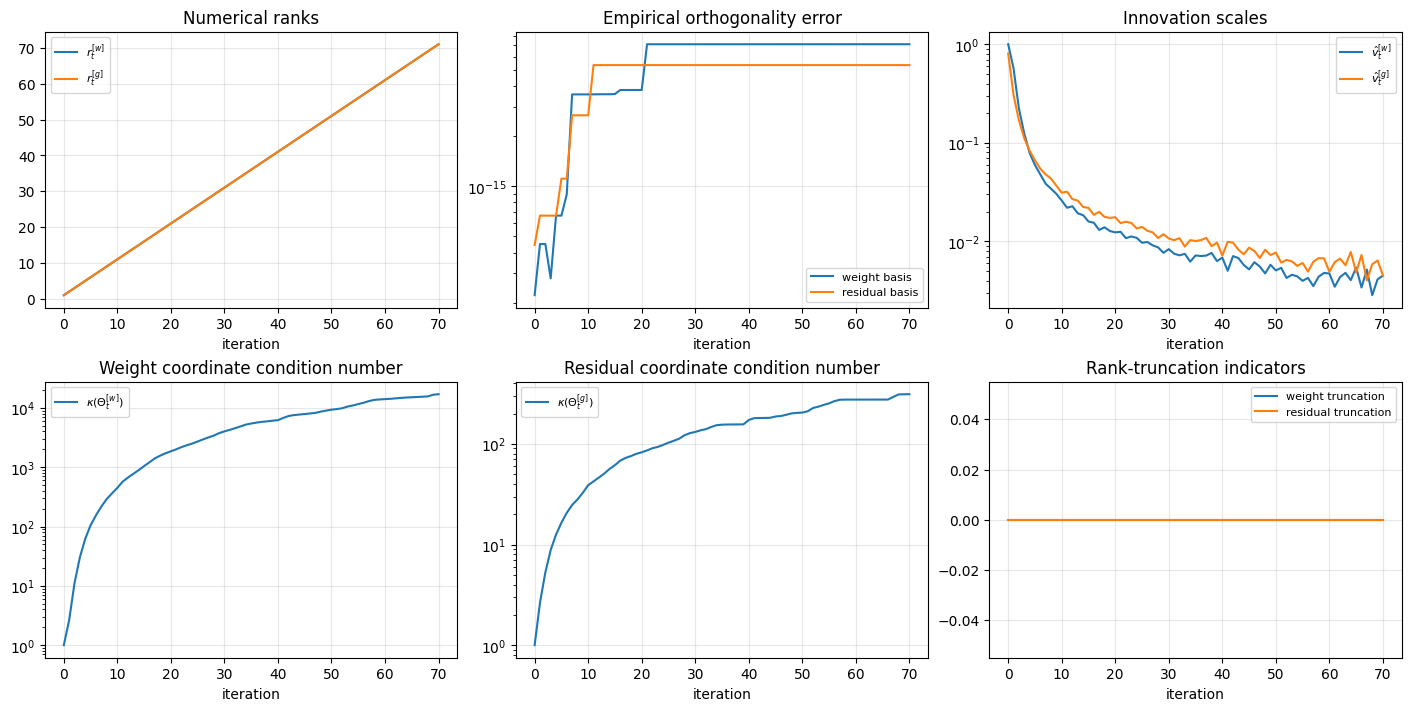

In [5]:
se = solutions[reference_key]
t = np.arange(T + 1)
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
axes[0, 0].plot(t, as_numpy(se.weight_rank), label=r"$r_t^{[w]}$")
axes[0, 0].plot(t, as_numpy(se.residual_rank), label=r"$r_t^{[g]}$")
axes[0, 1].semilogy(t, as_numpy(se.weight_orthogonality_error), label="weight basis")
axes[0, 1].semilogy(t, as_numpy(se.residual_orthogonality_error), label="residual basis")
axes[0, 2].semilogy(t, as_numpy(se.forward_innovation_scale), label=r"$\hat v_t^{[w]}$")
axes[0, 2].semilogy(t, as_numpy(se.backward_innovation_scale), label=r"$\hat v_t^{[g]}$")
axes[1, 0].semilogy(t, as_numpy(se.weight_coordinate_condition_number), label=r"$\kappa(\Theta_t^{[w]})$")
axes[1, 1].semilogy(t, as_numpy(se.residual_coordinate_condition_number), label=r"$\kappa(\Theta_t^{[g]})$")
axes[1, 2].plot(t, np.asarray(se.weight_rank_truncated, dtype=float), label="weight truncation")
axes[1, 2].plot(t, np.asarray(se.residual_rank_truncated, dtype=float), label="residual truncation")
for ax in axes.flat: ax.set_xlabel("iteration"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0, 0].set_title("Numerical ranks"); axes[0, 1].set_title("Empirical orthogonality error"); axes[0, 2].set_title("Innovation scales")
axes[1, 0].set_title("Weight coordinate condition number"); axes[1, 1].set_title("Residual coordinate condition number"); axes[1, 2].set_title("Rank-truncation indicators")
plt.show()

A conclusion from another notebook should be regarded as numerically robust only if it persists over the relevant $K_w,K_g$ and $\varepsilon_{\rm rank}$ range, without large basis-orthogonality errors or rank-truncation sensitivity.

## Repeated particle-budget uncertainty

The largest-budget reference is not an exact truth and therefore has zero discrepancy only by construction.  The opt-in calculation below uses independent seeds, reports per-observable uncertainty, and makes a $K^{-1/2}$ reference slope available for visual comparison.

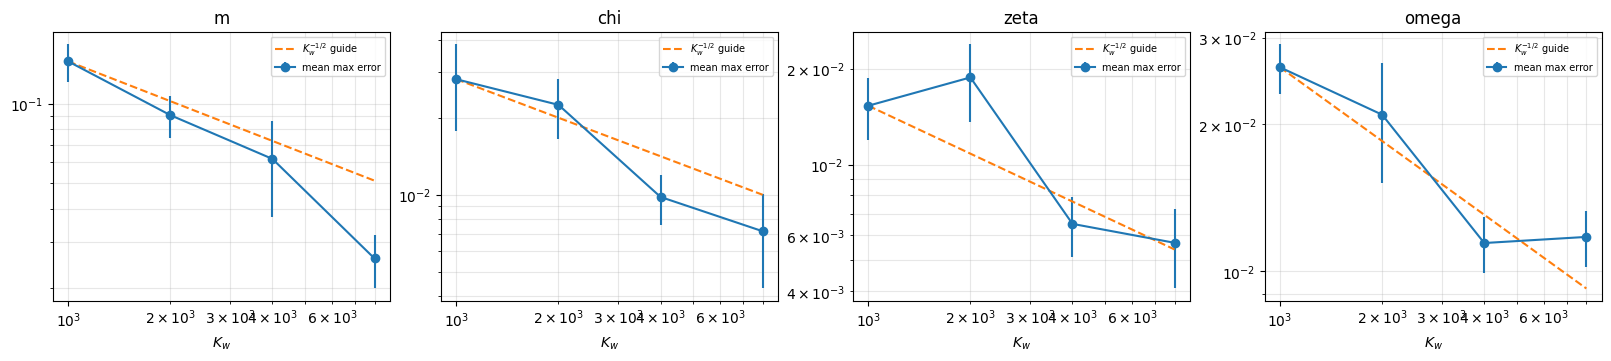

In [6]:
RUN_REPEATED_PARTICLE_BUDGETS = True
PARTICLE_SEEDS = (0, 1, 2, 3, 4)
if RUN_REPEATED_PARTICLE_BUDGETS:
    repeated_errors = {key: {name: [] for name in ("m", "chi", "zeta", "omega")} for key in BUDGETS}
    reference_budget = BUDGETS[-1]
    references = [run_solver(reference_budget[0], reference_budget[1], EPS_RANKS[0], mc_seed=SEED + seed) for seed in PARTICLE_SEEDS]
    reference_paths = {
        "m": [as_numpy(se.weight_signal_alignments) for se in references],
        "chi": [as_numpy(se.label_residual_alignments) for se in references],
        "zeta": [as_numpy(se.mean_residual) for se in references],
        "omega": [as_numpy(se.selection_rate) for se in references],
    }
    reference_mean = {name: mean_and_std(paths)[0] for name, paths in reference_paths.items()}
    for K_w, K_g in BUDGETS:
        for seed in PARTICLE_SEEDS:
            se = MacroscopicStateEvolution(data_cfg=DATA_CFG, algo_cfg=ALGO_CFG, mc_seed=SEED + seed, K=None, K_w=K_w, K_g=K_g, parameter_base_sampler=make_parameter_base_sampler(1.0), sample_base_sampler=state_evolution_sample_base_sampler(LAW))
            se.compute_trajectory()
            paths = {"m": as_numpy(se.weight_signal_alignments), "chi": as_numpy(se.label_residual_alignments), "zeta": as_numpy(se.mean_residual), "omega": as_numpy(se.selection_rate)}
            for name, path in paths.items(): repeated_errors[(K_w, K_g)][name].append(np.max(np.abs(path - reference_mean[name])))
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), constrained_layout=True)
    for ax, name in zip(axes, ("m", "chi", "zeta", "omega")):
        means = np.array([np.mean(repeated_errors[budget][name]) for budget in BUDGETS])
        ses = np.array([np.std(repeated_errors[budget][name], ddof=1) / np.sqrt(len(PARTICLE_SEEDS)) for budget in BUDGETS])
        ax.errorbar([budget[0] for budget in BUDGETS], means, yerr=ses, marker="o", label="mean max error")
        reference_slope = means[0] * np.sqrt(BUDGETS[0][0] / np.asarray([budget[0] for budget in BUDGETS]))
        ax.loglog([budget[0] for budget in BUDGETS], reference_slope, linestyle="--", label=r"$K_w^{-1/2}$ guide")
        ax.set(xscale="log", yscale="log", title=name, xlabel=r"$K_w$")
        ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=7)
    plt.show()